# 09 — NMF backend comparison: sklearn vs r1d

Tests the greedy rank-1 deflation factoriser (`r1d`) against sklearn NMF across two models:
- **8-4 (0134)** — SimpleMLP 784→8→4→2, even/odd on digits 0,1,3,4
- **40-20 (digits)** — SimpleMLP 784→40→20→10, full digit classification

**Sections**
1. Setup & data loading
2. Single-layer factor quality: reconstruction error, lambda profiles, sparsity
3. Full BFT timing comparison
4. BFT factor quality: class separability of img_factors, lambda profiles at root
5. Summary table

## 1. Setup

In [1]:
import sys, time
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

import torch

from src import (
    load_experiment, get_loaders_from_config, get_transform,
    collect_layer_inputs,
    full_nmf_pipeline, auto_nmf_pipeline,
    bft, extract_tree_nodes,
    run_r1d, rec_err_curve,
)
from src.bft import _partial_recon_errors

device = torch.device('cpu')
rng = np.random.default_rng(0)

In [2]:
EXPERIMENTS = {
    '8-4 (0134)': '../experiments/mnist_even_odd_mlp_8_4_0134',
    '40-20 (digits)': '../experiments/mnist_digit_mlp_40_20',
}

# BFT hyper-params (kept identical for both factorizers)
BFT_KWARGS = dict(
    k_max=8, n_branches=2,
    stimulus_threshold=0.0,
    weighting='img_selectivity',
    random_state=0,
    recon_threshold=0.2,
    verbose=1,
)

In [3]:
models, cfgs, layer_inputs_all, targets_all = {}, {}, {}, {}

for tag, exp_dir in EXPERIMENTS.items():
    model, cfg = load_experiment(exp_dir, device)
    label_transform = get_transform(cfg['label_transform'])
    _, test_loader = get_loaders_from_config(cfg)
    data = collect_layer_inputs(
        model, test_loader.dataset,
        label_transform=label_transform,
        n_per_class=None,
        device=device,
    )
    models[tag] = model
    cfgs[tag] = cfg
    layer_inputs_all[tag] = data['layer_inputs']
    targets_all[tag] = data['targets']
    n = data['layer_inputs'][0].shape[0]
    print(f"{tag}: {n} samples, arch {cfg['arch_kwargs']['hidden_dims']}")

8-4 (0134): 4078 samples, arch [8, 4]
40-20 (digits): 9560 samples, arch [40, 20]


## 2. Single-layer factor quality

Extract the joint arbor matrix for the **first (deepest) linear layer** of each model, then run both factorizers at a fixed rank and compare:
- Lambda profiles (component importance)
- Reconstruction error curves
- Sparsity of W and H

In [4]:
from src.bft import compute_joint_arbors_normalized
import numpy as np

def get_pos_joint(model, layer_inputs, layer_idx=0):
    """Build the positive joint arbor for a layer using uniform stimulus weights."""
    lin_idxs = model.linear_layer_indices()
    W = model.layers[lin_idxs[layer_idx]].weight.detach().numpy()
    act = layer_inputs[layer_idx]
    n = act.shape[0]
    sw = np.ones(n) / n
    raw = compute_joint_arbors_normalized(W, act, stimulus_weights=sw)
    return np.clip(raw, 0, None)

# Choose rank K for the fixed-rank comparison
K_COMPARE = 6

joint_arbors = {}
for tag in EXPERIMENTS:
    joint_arbors[tag] = get_pos_joint(models[tag], layer_inputs_all[tag], layer_idx=2)
    print(f"{tag}: joint arbor shape {joint_arbors[tag].shape}")

8-4 (0134): joint arbor shape (4078, 8)
40-20 (digits): joint arbor shape (9560, 200)


In [5]:
def sparsity(M):
    """Fraction of near-zero entries."""
    return float(np.isclose(M, 0).mean())

layer_results = {}  # tag -> dict of per-factorizer results

for tag in EXPERIMENTS:
    J = joint_arbors[tag]
    layer_results[tag] = {}
    for name, kwargs in [
        ('sklearn', dict(factorizer='sklearn')),
        ('r1d',     dict(factorizer='r1d', gamma=2)),
    ]:
        t0 = time.perf_counter()
        img_f, neu_f, lams = full_nmf_pipeline(J, K_COMPARE, **kwargs)
        t1 = time.perf_counter()
        recon_errs = _partial_recon_errors(J, img_f, neu_f)
        layer_results[tag][name] = dict(
            img_f=img_f, neu_f=neu_f, lams=lams,
            recon_errs=recon_errs,
            sparsity_W=sparsity(img_f),
            sparsity_H=sparsity(neu_f),
            time_s=t1 - t0,
        )
        k_actual = img_f.shape[1]
        print(f"  {tag} | {name:8s}: K={k_actual}  recon@K={recon_errs[-1]:.3f}  "
              f"sp_W={sparsity(img_f):.2f}  sp_H={sparsity(neu_f):.2f}  t={t1-t0:.3f}s")

  8-4 (0134) | sklearn : K=6  recon@K=0.000  sp_W=0.21  sp_H=0.56  t=0.013s
  8-4 (0134) | r1d     : K=4  recon@K=0.003  sp_W=0.50  sp_H=0.75  t=0.011s
  40-20 (digits) | sklearn : K=6  recon@K=0.265  sp_W=0.41  sp_H=0.62  t=0.293s
  40-20 (digits) | r1d     : K=6  recon@K=0.459  sp_W=0.67  sp_H=0.83  t=0.467s


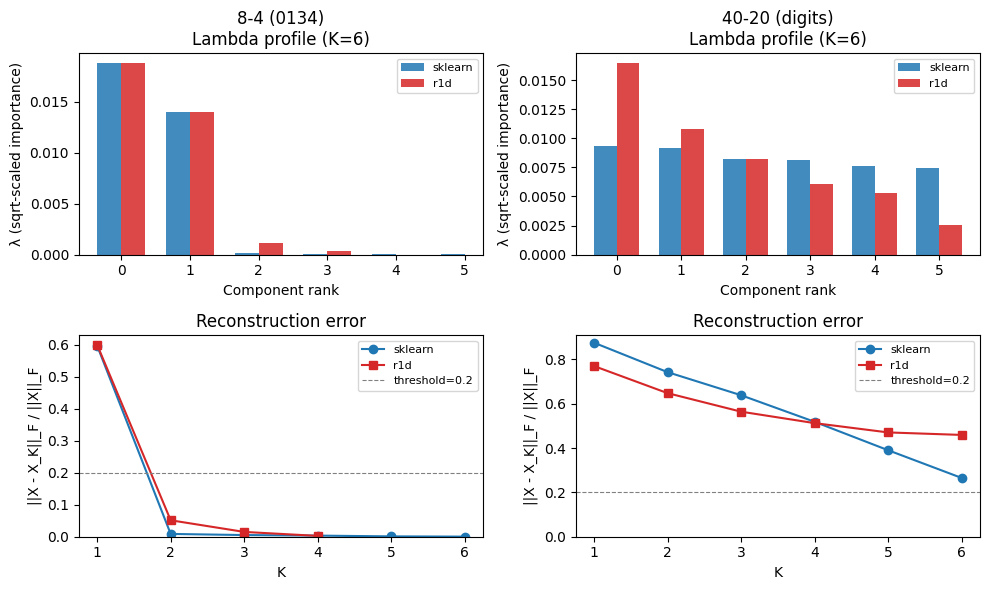

In [6]:
fig, axes = plt.subplots(2, len(EXPERIMENTS), figsize=(10, 6))
colors = {'sklearn': '#1f77b4', 'r1d': '#d62728'}
markers = {'sklearn': 'o', 'r1d': 's'}

for col, tag in enumerate(EXPERIMENTS):
    res = layer_results[tag]

    # ── top row: lambda profiles ─────────────────────────────────────────────
    ax = axes[0, col]
    x = np.arange(K_COMPARE)
    w = 0.35
    for i, (name, r) in enumerate(res.items()):
        k = len(r['lams'])
        ax.bar(x[:k] + (i - 0.5) * w, r['lams'], width=w,
               label=name, color=colors[name], alpha=0.85)
    ax.set_title(f'{tag}\nLambda profile (K={K_COMPARE})')
    ax.set_xlabel('Component rank')
    ax.set_ylabel('λ (sqrt-scaled importance)')
    ax.legend(fontsize=8)
    ax.set_xticks(x)

    # ── bottom row: reconstruction error curves ──────────────────────────────
    ax = axes[1, col]
    for name, r in res.items():
        k = len(r['recon_errs'])
        ax.plot(np.arange(1, k + 1), r['recon_errs'],
                marker=markers[name], color=colors[name], label=name, linewidth=1.5)
    ax.axhline(0.2, color='gray', linestyle='--', linewidth=0.8, label='threshold=0.2')
    ax.set_title('Reconstruction error')
    ax.set_xlabel('K')
    ax.set_ylabel('||X - X_K||_F / ||X||_F')
    ax.legend(fontsize=8)
    ax.set_ylim(0, None)

fig.tight_layout()
plt.show()

In [7]:
# Sparsity summary
print(f"{'Model':<20} {'factorizer':<10} {'sparsity W':>12} {'sparsity H':>12} {'time (s)':>10}")
print('-' * 68)
for tag in EXPERIMENTS:
    for name, r in layer_results[tag].items():
        print(f"{tag:<20} {name:<10} {r['sparsity_W']:>12.3f} {r['sparsity_H']:>12.3f} {r['time_s']:>10.4f}")

Model                factorizer   sparsity W   sparsity H   time (s)
--------------------------------------------------------------------
8-4 (0134)           sklearn           0.210        0.562     0.0132
8-4 (0134)           r1d               0.500        0.750     0.0106
40-20 (digits)       sklearn           0.413        0.620     0.2933
40-20 (digits)       r1d               0.667        0.826     0.4673


## 3. Full BFT timing comparison

Run the complete BFT tree with each factorizer on each model and record wall-clock time.

In [8]:
trees = {}  # (tag, factorizer) -> (tree_root, elapsed_s)

for tag in EXPERIMENTS:
    model = models[tag]
    layer_inputs = layer_inputs_all[tag]
    for name, fz_kwargs in [
        ('sklearn', dict(factorizer='sklearn')),
        ('r1d',     dict(factorizer='r1d', gamma=2)),
    ]:
        print(f"\n{'='*60}")
        print(f"  {tag} | {name}")
        print('='*60)
        t0 = time.perf_counter()
        root = bft(model, layer_inputs, **BFT_KWARGS, **fz_kwargs)
        elapsed = time.perf_counter() - t0
        trees[(tag, name)] = (root, elapsed)
        print(f"  → total BFT time: {elapsed:.3f} s")


  8-4 (0134) | sklearn
[BFT] Layer 3/3 '2' (fc)  path=[]  factorizer=sklearn
[BFT L3 '2' (fc)]   K=3  t=0.017s
[BFT] Layer 2/3 '1' (fc)  path=[0]  factorizer=sklearn
[BFT L2 '1' (fc)]   K=3  t=0.328s
[BFT] Layer 1/3 '0' (fc)  path=[0, 0]  factorizer=sklearn
[BFT L1 '0' (fc)]   K=8  t=10.772s
[BFT] Layer 1/3 '0' (fc)  path=[0, 1]  factorizer=sklearn
[BFT L1 '0' (fc)]   K=8  t=8.364s
[BFT] Layer 2/3 '1' (fc)  path=[1]  factorizer=sklearn
[BFT L2 '1' (fc)]   K=1  t=0.099s
[BFT] Layer 1/3 '0' (fc)  path=[1, 0]  factorizer=sklearn
[BFT L1 '0' (fc)]   K=8  t=13.273s
  → total BFT time: 32.855 s

  8-4 (0134) | r1d
[BFT] Layer 3/3 '2' (fc)  path=[]  factorizer=r1d
[BFT L3 '2' (fc)]   K=2  t=0.023s
[BFT] Layer 2/3 '1' (fc)  path=[0]  factorizer=r1d
[BFT L2 '1' (fc)]   K=1  t=0.047s
[BFT] Layer 1/3 '0' (fc)  path=[0, 0]  factorizer=r1d
[BFT L1 '0' (fc)]   K=8  t=7.028s
[BFT] Layer 2/3 '1' (fc)  path=[1]  factorizer=r1d
[BFT L2 '1' (fc)]   K=1  t=0.067s
[BFT] Layer 1/3 '0' (fc)  path=[1, 0]  fa

In [9]:
# Timing summary table
print(f"{'Model':<20} {'factorizer':<10} {'BFT time (s)':>14} {'speedup':>10}")
print('-' * 58)
for tag in EXPERIMENTS:
    t_sk = trees[(tag, 'sklearn')][1]
    t_r1 = trees[(tag, 'r1d')][1]
    for name, t in [('sklearn', t_sk), ('r1d', t_r1)]:
        ratio = t_sk / t if name == 'r1d' else 1.0
        ratio_str = f'{ratio:.2f}x' if name == 'r1d' else '—'
        print(f"{tag:<20} {name:<10} {t:>14.3f} {ratio_str:>10}")

Model                factorizer   BFT time (s)    speedup
----------------------------------------------------------
8-4 (0134)           sklearn            32.855          —
8-4 (0134)           r1d                14.094      2.33x
40-20 (digits)       sklearn           861.470          —
40-20 (digits)       r1d               626.712      1.37x


## 4. BFT factor quality

Compare the **root-node img_factors** from each factorizer:
- Lambda profile at the root
- Class separability: mean intra-class vs inter-class cosine similarity
- Hungarian-matched cosine similarity between sklearn and r1d factors

In [11]:
def cosine_sim_matrix(A, B):
    """Pairwise cosine similarity between columns of A and B."""
    An = A / (np.linalg.norm(A, axis=0, keepdims=True) + 1e-12)
    Bn = B / (np.linalg.norm(B, axis=0, keepdims=True) + 1e-12)
    return An.T @ Bn  # (ka, kb)

def hungarian_match_cosine(A, B):
    """Best-assignment mean cosine similarity between columns of A and B."""
    S = cosine_sim_matrix(A, B)  # (ka, kb)
    row, col = linear_sum_assignment(-S)
    return S[row, col].mean()

def class_separability(img_f, targets):
    """Mean intra-class minus inter-class cosine similarity of row vectors."""
    F = img_f / (np.linalg.norm(img_f, axis=1, keepdims=True) + 1e-12)
    S = F @ F.T  # (N, N)
    classes = np.unique(targets)
    intra, inter = [], []
    for i in range(len(S)):
        for j in range(i + 1, len(S)):
            if targets[i] == targets[j]:
                intra.append(S[i, j])
            else:
                inter.append(S[i, j])
    return np.mean(intra), np.mean(inter)

quality = {}  # tag -> dict

for tag in EXPERIMENTS:
    quality[tag] = {}
    tgts = targets_all[tag]
    root_sk = trees[(tag, 'sklearn')][0]
    root_r1 = trees[(tag, 'r1d')][0]
    
    for name, root in [('sklearn', root_sk), ('r1d', root_r1)]:
        img_f = root['img_factors']
        lams  = root['lambdas']
        intra, inter = class_separability(img_f, tgts)
        quality[tag][name] = dict(
            img_f=img_f, lams=lams,
            intra=intra, inter=inter,
            sep=intra - inter,
        )
        print(f"{tag} | {name:8s}: K={len(lams)}  "
              f"intra={intra:.3f}  inter={inter:.3f}  sep={intra-inter:.3f}")
    
    # Hungarian match
    img_sk = quality[tag]['sklearn']['img_f']
    img_r1 = quality[tag]['r1d']['img_f']
    hm = hungarian_match_cosine(img_sk, img_r1)
    quality[tag]['hungarian_cos'] = hm
    print(f"  → Hungarian cosine sim sklearn↔r1d: {hm:.3f}")

8-4 (0134) | sklearn : K=3  intra=0.959  inter=0.016  sep=0.943
8-4 (0134) | r1d     : K=2  intra=0.998  inter=0.008  sep=0.990
  → Hungarian cosine sim sklearn↔r1d: 0.997
40-20 (digits) | sklearn : K=8  intra=0.953  inter=0.349  sep=0.604
40-20 (digits) | r1d     : K=8  intra=0.875  inter=0.351  sep=0.524
  → Hungarian cosine sim sklearn↔r1d: 0.649


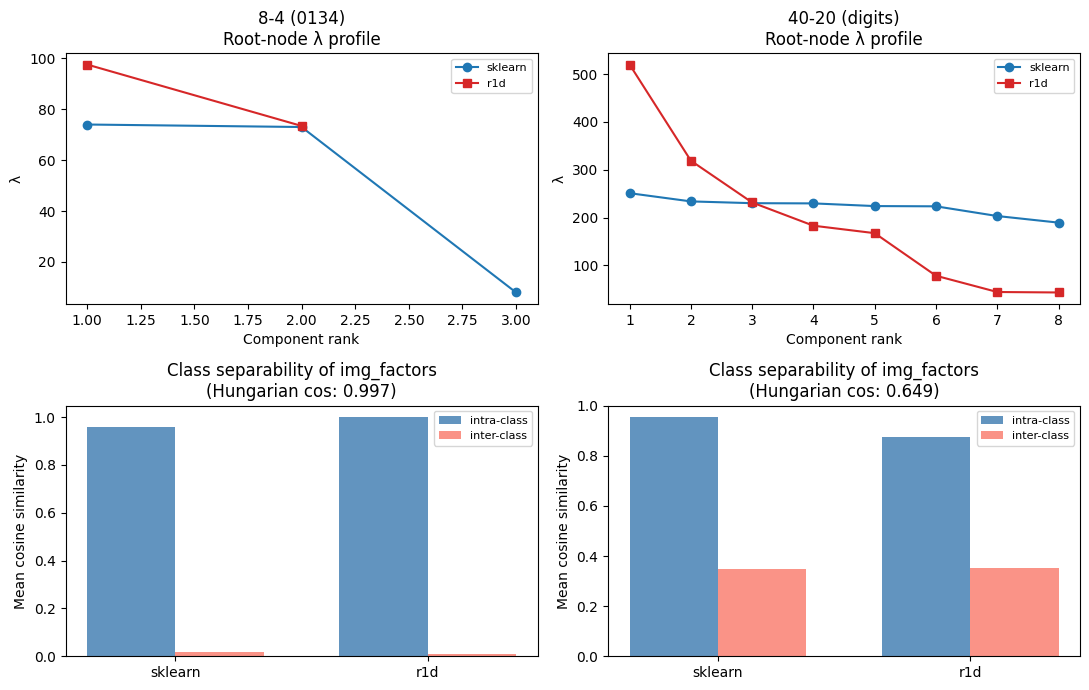

In [12]:
fig, axes = plt.subplots(2, len(EXPERIMENTS), figsize=(11, 7))

for col, tag in enumerate(EXPERIMENTS):
    q = quality[tag]

    # ── top row: root lambda profiles ────────────────────────────────────────
    ax = axes[0, col]
    for i, (name, r) in enumerate([(n, q[n]) for n in ('sklearn', 'r1d')]):
        k = len(r['lams'])
        ax.plot(np.arange(1, k + 1), r['lams'],
                marker=markers[name], color=colors[name], label=name, linewidth=1.5)
    ax.set_title(f'{tag}\nRoot-node λ profile')
    ax.set_xlabel('Component rank')
    ax.set_ylabel('λ')
    ax.legend(fontsize=8)

    # ── bottom row: class separability bar ───────────────────────────────────
    ax = axes[1, col]
    names_order = ['sklearn', 'r1d']
    x = np.arange(len(names_order))
    intra_vals = [q[n]['intra'] for n in names_order]
    inter_vals = [q[n]['inter'] for n in names_order]
    w = 0.35
    ax.bar(x - w/2, intra_vals, width=w, label='intra-class', color='steelblue', alpha=0.85)
    ax.bar(x + w/2, inter_vals, width=w, label='inter-class', color='salmon', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(names_order)
    ax.set_ylabel('Mean cosine similarity')
    ax.set_title(f'Class separability of img_factors\n(Hungarian cos: {q["hungarian_cos"]:.3f})')
    ax.legend(fontsize=8)
    ax.set_ylim(0, None)

fig.tight_layout()
plt.show()

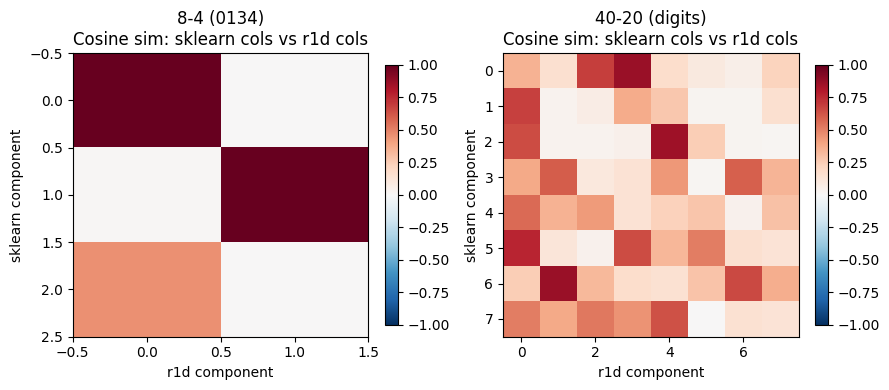

In [13]:
# Cross-factorizer cosine similarity heatmap at root
fig, axes = plt.subplots(1, len(EXPERIMENTS), figsize=(9, 4))

for ax, tag in zip(axes, EXPERIMENTS):
    img_sk = quality[tag]['sklearn']['img_f']
    img_r1 = quality[tag]['r1d']['img_f']
    S = cosine_sim_matrix(img_sk, img_r1)  # (K_sk, K_r1)
    im = ax.imshow(S, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.04)
    ax.set_title(f'{tag}\nCosine sim: sklearn cols vs r1d cols')
    ax.set_xlabel('r1d component')
    ax.set_ylabel('sklearn component')

fig.tight_layout()
plt.show()

## 5. Auto-rank selection comparison

Run `auto_nmf_pipeline` on the joint arbors at `k_max=12` and compare which K* is selected by each factorizer.

In [14]:
K_MAX_AUTO = 12

print(f"{'Model':<20} {'factorizer':<10} {'K_max':>6} {'K*':>5} {'recon@K*':>10} {'time (s)':>10}")
print('-' * 67)

auto_results = {}
for tag in EXPERIMENTS:
    J = joint_arbors[tag]
    auto_results[tag] = {}
    for name, fz_kw in [('sklearn', {}), ('r1d', dict(gamma=2))]:
        t0 = time.perf_counter()
        img_f, neu_f, lams, k_star = auto_nmf_pipeline(
            J, k_max=K_MAX_AUTO, recon_threshold=0.2,
            factorizer=name, **fz_kw
        )
        elapsed = time.perf_counter() - t0
        recon_at_kstar = _partial_recon_errors(J, img_f, neu_f)[-1]
        auto_results[tag][name] = dict(k_star=k_star, recon=recon_at_kstar, t=elapsed)
        print(f"{tag:<20} {name:<10} {K_MAX_AUTO:>6} {k_star:>5} {recon_at_kstar:>10.3f} {elapsed:>10.4f}")

Model                factorizer  K_max    K*   recon@K*   time (s)
-------------------------------------------------------------------
8-4 (0134)           sklearn        12     6      0.185     0.0165
8-4 (0134)           r1d            12     2      0.051     0.0100
40-20 (digits)       sklearn        12    11      0.177     1.1435
40-20 (digits)       r1d            12    12      0.435     0.6657


## 6. Summary table

In [15]:
print("\n" + "="*90)
print("SUMMARY")
print("="*90)
header = (f"{'Model':<20} {'factorizer':<10} {'BFT t(s)':>9} {'speedup':>8} "
          f"{'K* root':>8} {'intra':>7} {'inter':>7} {'sep':>7} {'hungarian':>10}")
print(header)
print('-' * 90)

for tag in EXPERIMENTS:
    t_sk = trees[(tag, 'sklearn')][1]
    t_r1 = trees[(tag, 'r1d')][1]
    for name in ('sklearn', 'r1d'):
        t = trees[(tag, name)][1]
        speedup = t_sk / t if name == 'r1d' else 1.0
        sp_str = f'{speedup:.2f}x' if name == 'r1d' else '—'
        q = quality[tag][name]
        hm = quality[tag]['hungarian_cos'] if name == 'r1d' else '—'
        hm_str = f'{hm:.3f}' if name == 'r1d' else '—'
        k_root = len(q['lams'])
        print(f"{tag:<20} {name:<10} {t:>9.3f} {sp_str:>8} "
              f"{k_root:>8} {q['intra']:>7.3f} {q['inter']:>7.3f} {q['sep']:>7.3f} {hm_str:>10}")
    print()


SUMMARY
Model                factorizer  BFT t(s)  speedup  K* root   intra   inter     sep  hungarian
------------------------------------------------------------------------------------------
8-4 (0134)           sklearn       32.855        —        3   0.959   0.016   0.943          —
8-4 (0134)           r1d           14.094    2.33x        2   0.998   0.008   0.990      0.997

40-20 (digits)       sklearn      861.470        —        8   0.953   0.349   0.604          —
40-20 (digits)       r1d          626.712    1.37x        8   0.875   0.351   0.524      0.649

